# Acreción utilizando las correcciones del código de Claude
### Ahora aparece un factor de eficiencia en la acreción $\lambda$ y desaparece el factor de acreción 

In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from PBHBeta import constants
import functionscorr as fn_comp
import jax
import jax.numpy as jnp
from scipy.optimize import brentq   
import equinox as eqx 
import jax.lax as lax
from diffrax import diffeqsolve, ODETerm, Tsit5, PIDController, SaveAt

1. Evaluando restricción exclusiva de Materia Oscura (DM)...

Calculando dinámica para lambda = 0.5...
   -> mu analítico = 1.299
   -> Mc analítica = 4.212e+02 g
   -> Mc numérica  = 5.161e+02 g

Calculando dinámica para lambda = 1.0...
   -> mu analítico = 1.852
   -> Mc analítica = 2.954e+02 g
   -> Mc numérica  = 3.128e+02 g

Calculando dinámica para lambda = 1.5...
   -> mu analítico = 3.226
   -> Mc analítica = 1.696e+02 g
   -> Mc numérica  = 1.714e+02 g

Calculando dinámica para lambda = 2.0...
   -> mu analítico = 12.500
   -> Mc analítica = 4.376e+01 g
   -> Mc numérica  = 4.388e+01 g


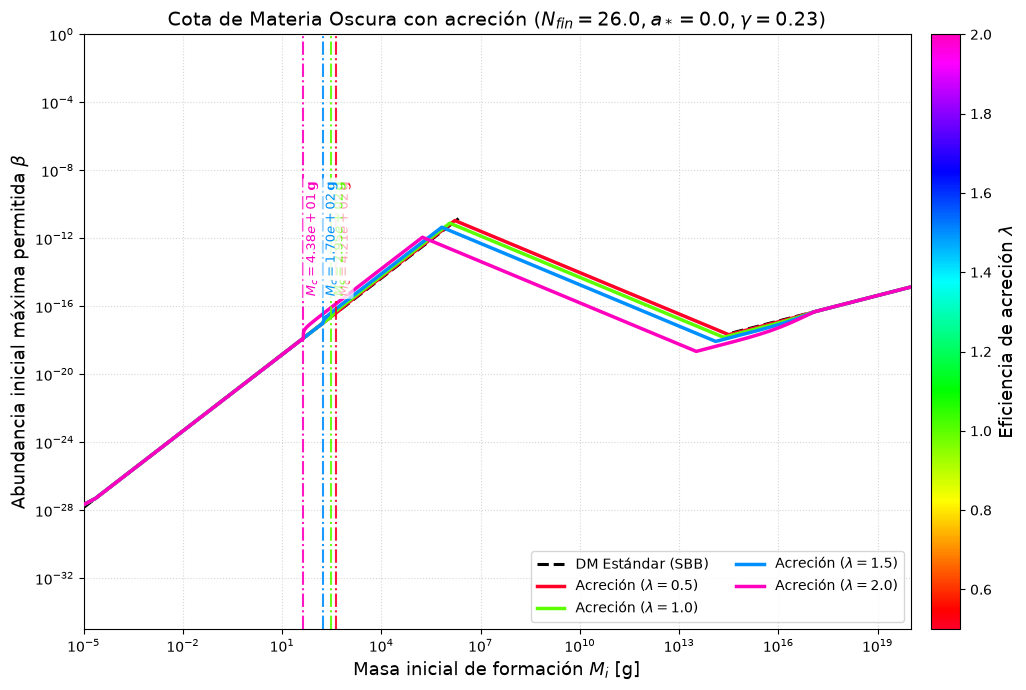

In [5]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []

# ====================================================================
# CÁLCULO DE MASA CRÍTICA: ANALÍTICA Y NUMÉRICA
# ====================================================================

def encontrar_masa_critica_num(N_fin, a_star, lam_efectivo, gamma_val):
    """
    Encuentra la masa exacta de transición usando el integrador JAX principal.
    """
    def balance_neto(log_Mi):
        Mi_g = 10.0**log_Mi
        Mi_jnp = jnp.array([Mi_g], dtype=jnp.float64)
        
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(
            Mi_jnp, N_fin, a_star, lam=lam_efectivo, gamma=gamma_val
        )
        
        Mf_g = float(M_f_tot_jnp[0])
        return float(np.log10(Mf_g / Mi_g))

    try:
        log_Mc = brentq(balance_neto, -2.0, 10.0, xtol=1e-4)
        return 10.0**log_Mc
    except ValueError as e:
        print(f"Advertencia: No se encontró masa crítica numérica para lambda={lam_efectivo}. Error: {e}")
        return None

# ====================================================================
# GRAFICACIÓN EXCLUSIVA DE MATERIA OSCURA
# ====================================================================

def graficar_solo_DM():
    print("1. Evaluando restricción exclusiva de Materia Oscura (DM)...")
    
    M_tot = fn_comp.put_M_array(1e-5, 1e22, num_points_low=10000) 
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    
    omega_sbb = 1.0 / 3.0  
    N_fin = 26.0
    a_star = 0.0
    gamma_val = 0.23  
    
    # Calcular línea base SBB 
    limpiar_memoria()
    fn_comp.Betas_DM(M_tot, omega_sbb)
    beta_dm_sbb = np.array(fn_comp.constraints.betas_DM_tot)
    
    fig, ax = plt.subplots(figsize=(11, 7))
    b_sbb_plot = np.where(beta_dm_sbb == fn_comp.constants.ev1, np.nan, beta_dm_sbb)
    ax.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='DM Estándar (SBB)', zorder=2)
    
    # ---------------------------------------------------------
    # CONFIGURACIÓN DEL MAPA DE COLORES (COLORBAR)
    # ---------------------------------------------------------
    lam_list = [0.5, 1.0, 1.5, 2.0]
    cmap = plt.get_cmap('gist_rainbow')
    norm = mcolors.Normalize(vmin=0.5, vmax=2.0)
    
    for lam in lam_list:
        print(f"\nCalculando dinámica para lambda = {lam}...")
        color_lam = cmap(norm(lam))
        
        # 1. Masa crítica analítica y numérica
        Mc_analitica, mu_analitico = fn_comp.calcular_masa_critica_analitica(N_fin, a_star, lam, gamma_val)
        Mc_num = encontrar_masa_critica_num(N_fin, a_star, lam, gamma_val)
        
        print(f"   -> mu analítico = {mu_analitico:.3f}")
        print(f"   -> Mc analítica = {Mc_analitica:.3e} g")
        if Mc_num is not None:
            print(f"   -> Mc numérica  = {Mc_num:.3e} g")
        
        # 2. Integración de masas usando JAX
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(
            M_tot_jnp, N_fin, a_star, lam=lam, gamma=gamma_val
        )
        
        # 3. Corrimiento de las restricciones
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), beta_dm_sbb)
        
        # 4. Trazar el espectro
        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        ax.plot(M_tot, b_plot, color=color_lam, lw=2.5, 
                label=rf'Acreción ($\lambda={lam}$)', zorder=3)
        
        # 5. Trazar línea vertical y texto anotado sobre el plot
        ax.axvline(x=Mc_analitica, color=color_lam, linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
        
        # Posicionamiento del texto vertical directamente sobre la línea
        # Se aplica un ligero desplazamiento multiplicativo en x para que no tape el trazo
        y_pos = 1e-12
        x_text_pos = Mc_analitica * 1.15
        
        ax.text(
            x_text_pos, y_pos, 
            rf'$M_c = {Mc_analitica:.2e}\,$g', 
            color=color_lam, 
            rotation=90, 
            verticalalignment='center', 
            horizontalalignment='left',
            fontsize=9.5, 
            fontweight='bold',
            zorder=5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.65, edgecolor='none')
        )

    # ---------------------------------------------------------
    # INSERCIÓN DEL COLORBAR
    # ---------------------------------------------------------
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'Eficiencia de acreción $\lambda$', fontsize=13)

    # ---------------------------------------------------------
    # FORMATO DE LA GRÁFICA
    # ---------------------------------------------------------
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'Masa inicial de formación $M_i$ [g]', fontsize=13)
    ax.set_ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=13)
    ax.set_title(rf'Cota de Materia Oscura con acreción ($N_{{fin}}={N_fin}, a_*={a_star}, \gamma={gamma_val}$)', fontsize=14)
    ax.set_xlim(1e-5, 1e20)
    ax.set_ylim(1e-35, 1e0)
    ax.grid(True, which='both', ls=':', alpha=0.5)
    ax.legend(fontsize=10, loc='lower right', ncol=2)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    graficar_solo_DM()


2. Evaluando constraints completas barriendo N_fin...
   -> Calculando espectro completo de restricciones SBB...
   -> Integrando N_fin = 15.0...
   -> Integrando N_fin = 20.0...
   -> Integrando N_fin = 25.0...
   -> Integrando N_fin = 30.0...


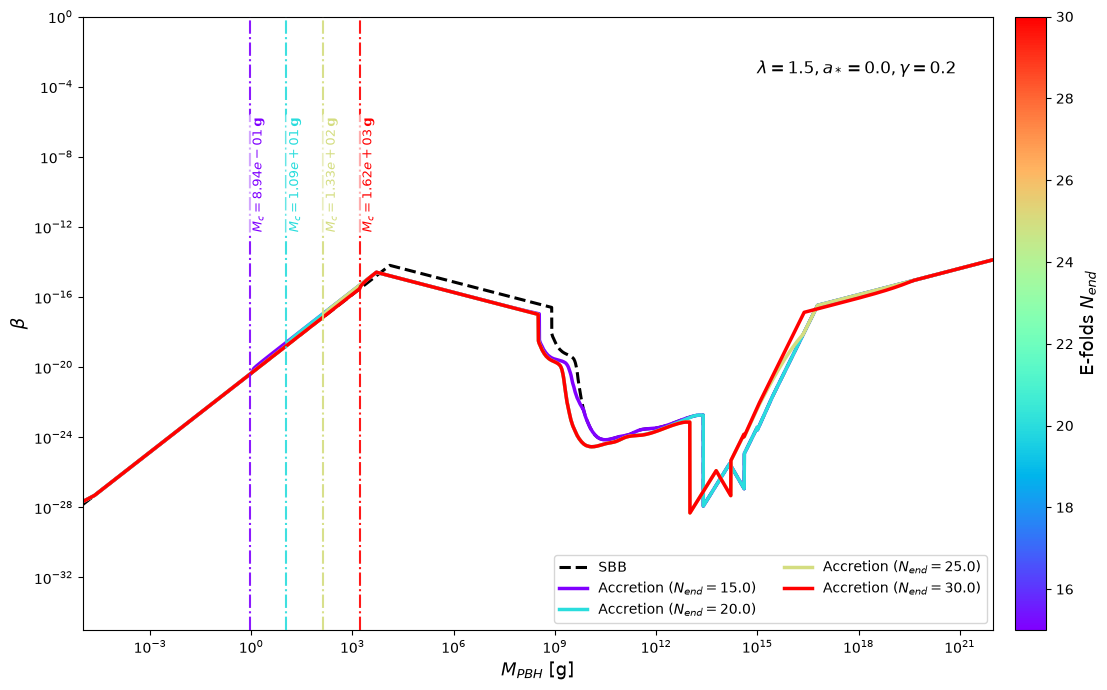

In [9]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []

def calcular_envolvente_sbb(M_tot, omega_sbb):
    """
    Evalúa todas las restricciones físicas sin acreción (SBB) y 
    devuelve la curva envolvente (el límite más estricto).
    """
    limpiar_memoria()
    print("   -> Calculando espectro completo de restricciones SBB...")
    fn_comp.Betas_DM(M_tot, omega_sbb)
    fn_comp.Betas_BBN(M_tot, omega_sbb)
    fn_comp.Betas_SD(M_tot, omega_sbb)
    fn_comp.Betas_CMB_AN(M_tot, omega_sbb)
    fn_comp.Betas_GRB(M_tot, omega_sbb)
    fn_comp.Betas_Reio(M_tot, omega_sbb)
    fn_comp.Betas_LSP(M_tot, omega_sbb)
    
    # Extrae el mínimo de todas las restricciones evaluadas
    return fn_comp.get_Betas_full(M_tot)

# ====================================================================
# BARRIDO EN E-FOLDS (N_fin) PARA TODAS LAS RESTRICCIONES
# ====================================================================

def graficar_efolds():
    print("2. Evaluando constraints completas barriendo N_fin...")
    
    # Rango extendido para no cortar la gráfica
    M_tot = fn_comp.put_M_array(1e-5, 1e22, num_points_low=10000)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    omega_sbb = 1.0 / 3.0
    
    # 1. GENERAR LA ENVOLVENTE SBB BASE
    betas_sbb_full = calcular_envolvente_sbb(M_tot, omega_sbb)
    b_sbb_plot = np.where(betas_sbb_full == fn_comp.constants.ev1, np.nan, betas_sbb_full)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='SBB')
    
    # Parámetros físicos constantes
    lam = 1.5 
    a_star = 0.0
    gamma_val = 0.2  # Eficiencia del colapso en dominación de materia
    
    N_list = [15.0, 20.0, 25.0, 30.0]
    
    # ---------------------------------------------------------
    # CONFIGURACIÓN DEL MAPA DE COLORES (COLORBAR)
    # ---------------------------------------------------------
    cmap = plt.get_cmap('rainbow')
    norm = mcolors.Normalize(vmin=15.0, vmax=30.0)
    ax.text(
            1e15, 1e-3, 
            rf'$ \lambda = {lam},a_* = {a_star}, \gamma = {gamma_val}$', 
            color='black', 
            verticalalignment='center', 
            horizontalalignment='left',
            fontsize=12, 
            fontweight='bold',
            zorder=7,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.65, edgecolor='none')
        )
    for N_fin in N_list:
        print(f"   -> Integrando N_fin = {N_fin}...")
        color_n = cmap(norm(N_fin))
        
        Mc_analitica, mu_analitico = fn_comp.calcular_masa_critica_analitica(N_fin, a_star, lam, gamma_val)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, lam=lam, gamma=gamma_val)
        
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), betas_sbb_full)
        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        
        ax.plot(M_tot, b_plot, color=color_n, lw=2.5, label=rf'Accretion ($N_{{end}}={N_fin}$)')
        ax.axvline(x=Mc_analitica, color=color_n, linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
        y_pos = 1e-9
        x_text_pos = Mc_analitica * 1.15
        
        ax.text(
            x_text_pos, y_pos, 
            rf'$M_c = {Mc_analitica:.2e}\,$g', 
            color=color_n, 
            rotation=90, 
            verticalalignment='center', 
            horizontalalignment='left',
            fontsize=9.5, 
            fontweight='bold',
            zorder=5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.65, edgecolor='none')
        )
    # ---------------------------------------------------------
    # INSERCIÓN DEL COLORBAR
    # ---------------------------------------------------------
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'E-folds $N_{end}$', fontsize=13)

    # ---------------------------------------------------------
    # FORMATO
    # ---------------------------------------------------------
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$M_{PBH}$ [g]', fontsize=13)
    ax.set_ylabel(r'$\beta$', fontsize=13)
    #ax.set_title(rf'Restricciones variando el número de e-folds ($\lambda={lam}, \gamma={gamma_val}$)', fontsize=14)
    ax.set_xlim(1e-5, 1e22)
    ax.set_ylim(1e-35, 1e0)
    ax.grid(False)
    
    # Leyenda en dos columnas para mantener el gráfico limpio
    ax.legend(fontsize=10, loc='lower right', ncol=2)
    
    plt.tight_layout()
    plt.savefig('efoldsarray.png', dpi=300)
    plt.show()
    
if __name__ == "__main__":
    graficar_efolds()

3. Evaluando constraints completas barriendo el Espín (a_*)...


/home/javibiss/Descargas/PBH Accretion/PBHpy/functionscorr.py:408: RuntimeWarning: invalid value encountered in scalar power
  y_val = beta * sol_try.y[0][-1] * (1. - sol_try.y[1][-1] / Delta_t)**(1./3)
/home/javibiss/Descargas/PBH Accretion/PBHpy/functionscorr.py:611: RuntimeWarning: invalid value encountered in scalar power
  y_val = beta * sol_try.y[0][-1] * (1. - sol_try.y[1][-1] / Delta_t)**(1./3)


   -> Integrando a_* = 0.0...
   -> Integrando a_* = 0.7...
   -> Integrando a_* = 0.9...
   -> Integrando a_* = 0.99...


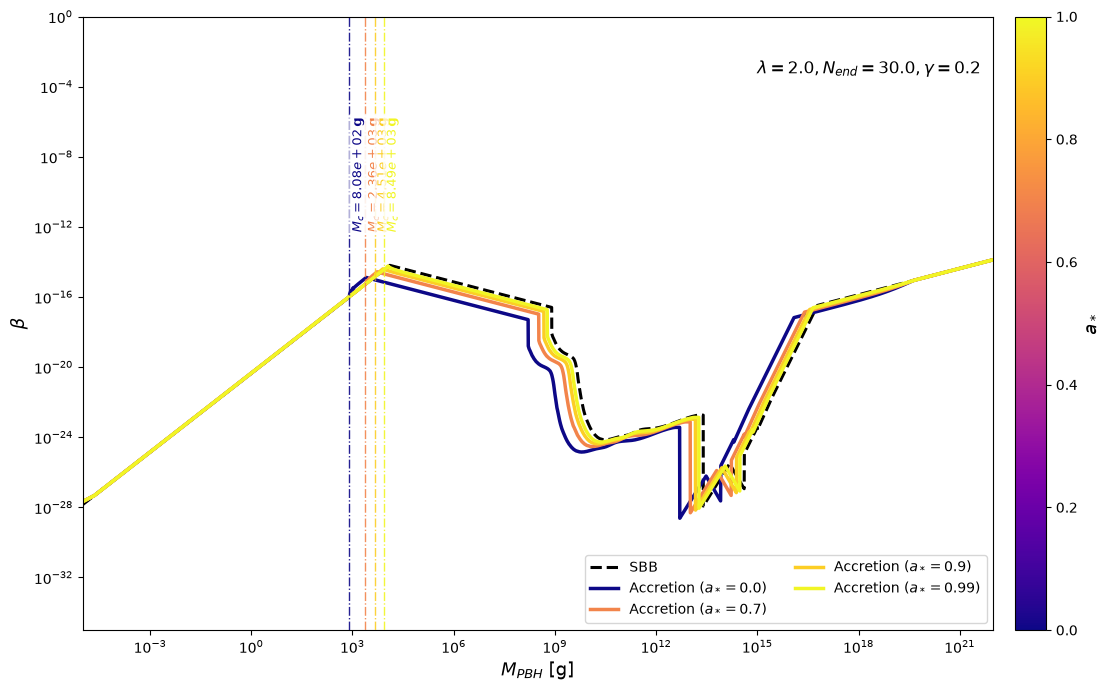

In [2]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []

def calcular_envolvente_sbb(M_tot, omega_sbb):
    """
    Evalúa todas las restricciones físicas sin acreción (SBB) y 
    devuelve la curva envolvente (el límite más estricto).
    """
    limpiar_memoria()
    fn_comp.Betas_DM(M_tot, omega_sbb)
    fn_comp.Betas_BBN(M_tot, omega_sbb)
    fn_comp.Betas_SD(M_tot, omega_sbb)
    fn_comp.Betas_CMB_AN(M_tot, omega_sbb)
    fn_comp.Betas_GRB(M_tot, omega_sbb)
    fn_comp.Betas_Reio(M_tot, omega_sbb)
    fn_comp.Betas_LSP(M_tot, omega_sbb)
    return fn_comp.get_Betas_full(M_tot)

# ====================================================================
# 3. BARRIDO EN ESPÍN (a_star) PARA TODAS LAS RESTRICCIONES
# ====================================================================

    
def graficar_espin():
    print("3. Evaluando constraints completas barriendo el Espín (a_*)...")
    
    # Rango extendido para no cortar la gráfica
    M_tot = fn_comp.put_M_array(1e-5, 1e22, num_points_low=10000)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    omega_sbb = 1.0 / 3.0
    
    # Generar la envolvente SBB
    betas_sbb_full = calcular_envolvente_sbb(M_tot, omega_sbb)
    b_sbb_plot = np.where(betas_sbb_full == fn_comp.constants.ev1, np.nan, betas_sbb_full)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='SBB')
    
    # Parámetros físicos
    lam = 2.0 
    N_fin = 30.0
    gamma_val = 0.2
    a_list = [0.0, 0.7, 0.9, 0.99]
    
    # ---------------------------------------------------------
    # CONFIGURACIÓN DEL MAPA DE COLORES (COLORBAR)
    # ---------------------------------------------------------
    cmap = plt.get_cmap('plasma') 
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
    
    ax.text(
            1e15, 1e-3, 
            rf'$ \lambda = {lam},N_{{end}} = {N_fin}, \gamma = {gamma_val}$', 
            color='black', 
            verticalalignment='center', 
            horizontalalignment='left',
            fontsize=12, 
            fontweight='bold',
            zorder=5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.65, edgecolor='none')
        )
    
    for a_star in a_list:
        print(f"   -> Integrando a_* = {a_star}...")
        color_a = cmap(norm(a_star))
        
        Mc_analitica, mu_analitico = fn_comp.calcular_masa_critica_analitica(N_fin, a_star, lam, gamma_val)
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, lam=lam, gamma=gamma_val)
        
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), betas_sbb_full)
        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        
        ax.plot(M_tot, b_plot, color=color_a, lw=2.5, label=rf'Accretion ($a_*={a_star}$)')
        
        ax.axvline(x=Mc_analitica, color=color_a, linestyle='-.', lw=1.0, alpha=0.9, zorder=4)
        y_pos = 1e-9
        x_text_pos = Mc_analitica * 1.15
        
        ax.text(
            x_text_pos, y_pos, 
            rf'$M_c = {Mc_analitica:.2e}\,$g', 
            color=color_a, 
            rotation=90, 
            verticalalignment='center', 
            horizontalalignment='left',
            fontsize=9.5, 
            fontweight='bold',
            zorder=5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.65, edgecolor='none')
        )
    # ---------------------------------------------------------
    # INSERCIÓN DEL COLORBAR
    # ---------------------------------------------------------
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'$a_*$', fontsize=13)

    # ---------------------------------------------------------
    # FORMATO
    # ---------------------------------------------------------
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$M_{PBH}$ [g]', fontsize=13)
    ax.set_ylabel(r'$\beta$', fontsize=13)
    #ax.set_title(rf'Transición de régimen según Espín inicial ($\lambda={lam}, N_{{fin}}={N_fin}, \gamma={gamma_val}$)', fontsize=14)
    ax.set_xlim(1e-5, 1e22)
    ax.set_ylim(1e-35, 1e0)
    ax.grid(False)
    
    ax.legend(fontsize=10, loc='lower right', ncol=2)
    
    plt.tight_layout()
    plt.savefig('spinarray.png', dpi=300)
    plt.show()    
    
if __name__ == "__main__":
    graficar_espin()

Evaluando constraints completas barriendo lambda...
   -> Calculando espectro completo de restricciones SBB...
   -> Integrando lambda = 0.5...
   -> Integrando lambda = 1.0...
   -> Integrando lambda = 1.5...
   -> Integrando lambda = 2.0...


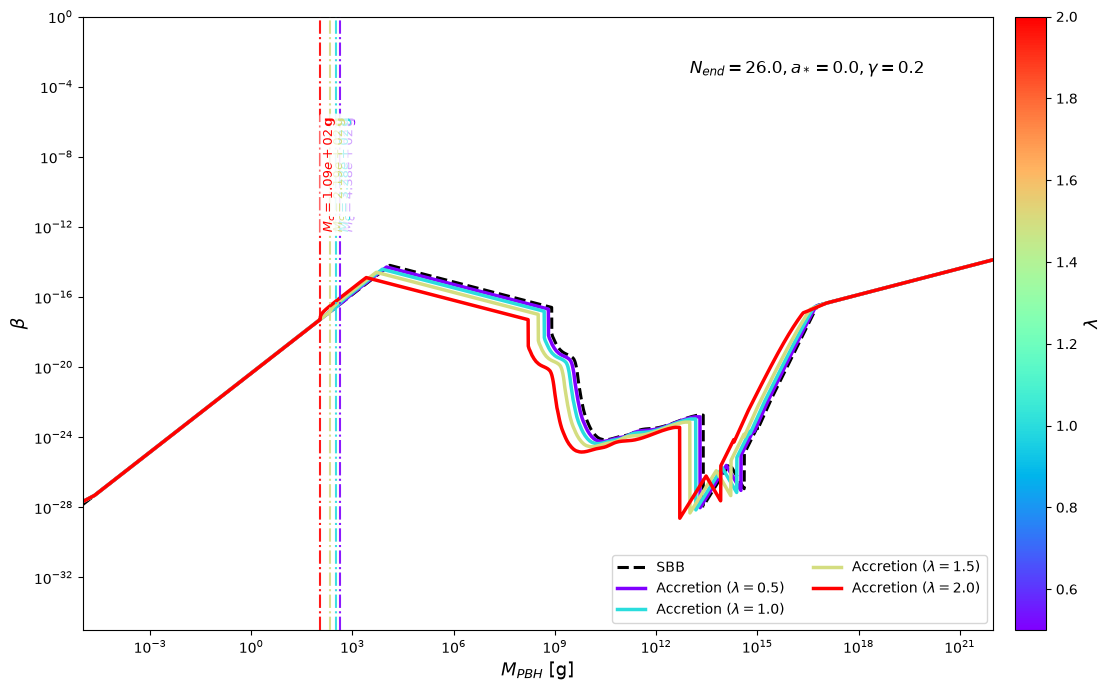

In [12]:
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para aislar las evaluaciones."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_LSP_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []

def calcular_envolvente_sbb(M_tot, omega_sbb):
    """
    Evalúa todas las restricciones físicas sin acreción (SBB) y 
    devuelve la curva envolvente (el límite más estricto).
    """
    limpiar_memoria()
    print("   -> Calculando espectro completo de restricciones SBB...")
    fn_comp.Betas_DM(M_tot, omega_sbb)
    fn_comp.Betas_BBN(M_tot, omega_sbb)
    fn_comp.Betas_SD(M_tot, omega_sbb)
    fn_comp.Betas_CMB_AN(M_tot, omega_sbb)
    fn_comp.Betas_GRB(M_tot, omega_sbb)
    fn_comp.Betas_Reio(M_tot, omega_sbb)
    fn_comp.Betas_LSP(M_tot, omega_sbb)
    
    return fn_comp.get_Betas_full(M_tot)

# ====================================================================
# BARRIDO EN EFICIENCIA DE ACRECIÓN (lambda) PARA TODAS LAS RESTRICCIONES
# ====================================================================

def graficar_lambda():
    print("Evaluando constraints completas barriendo lambda...")
    
    M_tot = fn_comp.put_M_array(1e-5, 1e22, num_points_low=10000)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64)
    omega_sbb = 1.0 / 3.0
    
    # 1. Generar la envolvente SBB base
    betas_sbb_full = calcular_envolvente_sbb(M_tot, omega_sbb)
    b_sbb_plot = np.where(betas_sbb_full == fn_comp.constants.ev1, np.nan, betas_sbb_full)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(M_tot, b_sbb_plot, 'k--', lw=2.2, label='SBB')
    
    # Parámetros físicos fijos
    N_fin = 26.0
    a_star = 0.0
    gamma_val = 0.2  # Eficiencia del colapso en dominación de materia
    
    # Lista de lambdas a barrer
    lam_list = [0.5, 1.0, 1.5, 2.0]
    
    # ---------------------------------------------------------
    # CONFIGURACIÓN DEL MAPA DE COLORES (COLORBAR)
    # ---------------------------------------------------------
    cmap = plt.get_cmap('rainbow')
    norm = mcolors.Normalize(vmin=0.5, vmax=2.0)
    
    ax.text(
        1e13, 1e-3, 
        rf'$N_{{end}} = {N_fin}, a_* = {a_star}, \gamma = {gamma_val}$', 
        color='black', 
        verticalalignment='center', 
        horizontalalignment='left',
        fontsize=12, 
        fontweight='bold',
        zorder=7,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.65, edgecolor='none')
    )

    for lam in lam_list:
        print(f"   -> Integrando lambda = {lam}...")
        color_lam = cmap(norm(lam))
        
        # Masa crítica analítica
        Mc_analitica, mu_analitico = fn_comp.calcular_masa_critica_analitica(N_fin, a_star, lam, gamma_val)
        
        # Integración JAX de la masa final
        M_f_tot_jnp, _ = fn_comp.precalcular_acreccion_lote(M_tot_jnp, N_fin, a_star, lam=lam, gamma=gamma_val)
        
        # Mapeo del corrimiento a la envolvente global
        beta_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, np.array(M_f_tot_jnp), betas_sbb_full)
        b_plot = np.where(beta_acc == fn_comp.constants.ev1, np.nan, beta_acc)
        
        ax.plot(M_tot, b_plot, color=color_lam, lw=2.5, label=rf'Accretion ($\lambda={lam}$)')
        ax.axvline(x=Mc_analitica, color=color_lam, linestyle='-.', lw=1.5, alpha=0.9, zorder=4)
        
        y_pos = 1e-9
        x_text_pos = Mc_analitica * 1.15
        
        ax.text(
            x_text_pos, y_pos, 
            rf'$M_c = {Mc_analitica:.2e}\,$g', 
            color=color_lam, 
            rotation=90, 
            verticalalignment='center', 
            horizontalalignment='left',
            fontsize=9.5, 
            fontweight='bold',
            zorder=5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.65, edgecolor='none')
        )

    # ---------------------------------------------------------
    # INSERCIÓN DEL COLORBAR
    # ---------------------------------------------------------
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'$\lambda$', fontsize=13)

    # ---------------------------------------------------------
    # FORMATO
    # ---------------------------------------------------------
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$M_{PBH}$ [g]', fontsize=13)
    ax.set_ylabel(r'$\beta$', fontsize=13)
    ax.set_xlim(1e-5, 1e22)
    ax.set_ylim(1e-35, 1e0)
    ax.grid(False)
    
    ax.legend(fontsize=10, loc='lower right', ncol=2)
    
    plt.tight_layout()
    plt.savefig('lambda_array.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    graficar_lambda()

1/4 - Generando espacio de masas...
2/4 - Evaluando modelo Estándar (SBB)...
3/4 - JAX: Calculando dinámica de acreción de onda y aplicando shift...
4/4 - Procesando gráfica comparativa...


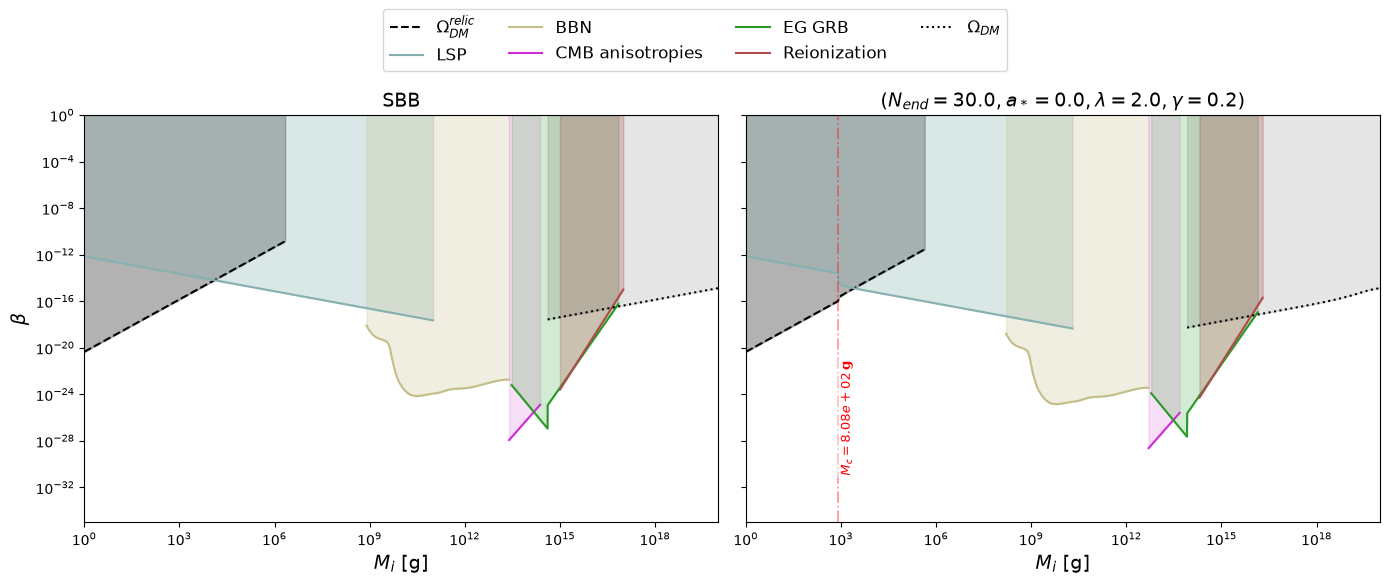

In [32]:
    
def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    fn_comp.constraints.betas_DM_tot = []
    fn_comp.constraints.betas_BBN_tot = []
    fn_comp.constraints.betas_SD_tot = []
    fn_comp.constraints.betas_CMB_AN_tot = []
    fn_comp.constraints.betas_GRB_tot = []
    fn_comp.constraints.betas_Reio_tot = []
    fn_comp.constraints.betas_LSP_tot = []

def clean_beta(b):
    """Enmascara los valores inválidos (ev1) con NaN para que matplotlib no trace caídas falsas."""
    return np.where(b == constants.ev1, np.nan, b)

def graficar_comparativa_espectros():
    print("1/4 - Generando espacio de masas...")
    M_tot = fn_comp.put_M_array(1e-5, 1e22)
    M_tot_jnp = jnp.array(M_tot, dtype=jnp.float64) 
    
    # Parámetros cosmológicos y termodinámicos
    omega = 1.0/3.0 # Las restricciones estándar SBB se mapean en radiación
    N_fin = 30.00
    a_star = 0.0
    lam = 2.0 # Parámetro lambda
    gamma_val = 0.2 # Eficiencia de colapso en dominación de materia
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/4 - Evaluando modelo Estándar (SBB)...")
    limpiar_memoria()
    
    # Calculamos las envolventes base
    fn_comp.Betas_DM(M_tot, omega)
    fn_comp.Betas_LSP(M_tot, omega)
    fn_comp.Betas_BBN(M_tot, omega)
    fn_comp.Betas_CMB_AN(M_tot, omega)
    fn_comp.Betas_GRB(M_tot, omega)
    fn_comp.Betas_Reio(M_tot, omega)

    # Extraemos las matrices completas SBB
    b_dm_std = np.array(fn_comp.constraints.betas_DM_tot)
    b_lsp_std = np.array(fn_comp.constraints.betas_LSP_tot)
    b_bbn_std = np.array(fn_comp.constraints.betas_BBN_tot)
    b_cmb_std = np.array(fn_comp.constraints.betas_CMB_AN_tot)
    b_grb_std = np.array(fn_comp.constraints.betas_GRB_tot)
    b_reio_std = np.array(fn_comp.constraints.betas_Reio_tot)

    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX) Y CORRIMIENTO EXACTO
    # ---------------------------------------------------------
    print("3/4 - JAX: Calculando dinámica de acreción de onda y aplicando shift...")
    
    # Llamamos al integrador pasándole el nuevo parámetro gamma_val
    M_f_tot_jnp, mu_tot_jnp = fn_comp.precalcular_acreccion_lote(
        M_tot_jnp, float(N_fin), float(a_star), lam=lam, gamma=gamma_val
    )
    
    # Estabilizamos el ruido numérico para asegurar masa creciente
    M_f_tot = np.maximum.accumulate(np.array(M_f_tot_jnp))
    mu_tot = M_f_tot / M_tot
    
    Mc_analitica, mu_analitico = fn_comp.calcular_masa_critica_analitica(N_fin, a_star, lam, gamma_val)
    # Aplicamos el corrimiento (shift) a cada matriz por separado
    b_dm_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_dm_std)
    b_lsp_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_lsp_std)
    b_bbn_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_bbn_std)
    b_cmb_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_cmb_std)
    b_grb_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_grb_std)
    b_reio_acc = fn_comp.aplicar_corrimiento_acrecion(M_tot, M_f_tot, b_reio_std)

    # Separación visual de Materia Oscura en Reliquias (línea dashed) y Macroscópicos (línea dotted)
    mask_relic_std = M_tot <= 1e11 * constants.M_pl_g
    mask_macro_std = M_tot > 4.1e14
    b_relic_std = np.where(mask_relic_std, b_dm_std, constants.ev1)
    b_macro_std = np.where(mask_macro_std, b_dm_std, constants.ev1)

    mask_relic_acc = M_f_tot <= 1e11 * constants.M_pl_g
    mask_macro_acc = M_f_tot > 4.1e14
    b_relic_acc = np.where(mask_relic_acc, b_dm_acc, constants.ev1)
    b_macro_acc = np.where(mask_macro_acc, b_dm_acc, constants.ev1)

    # ---------------------------------------------------------
    # 3. GRAFICACIÓN PARALELA
    # ---------------------------------------------------------
    print("4/4 - Procesando gráfica comparativa...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    colores = {
        'relic': 'black', 'lsp': '#87B0B0', 'bbn': '#C4BE88',
        'cmb': '#D12BD4', 'grb': '#279A25', 'reio': '#B14A4D', 'dm': 'black'
    }

    def plot_y_sombrear(ax, y_arr, color, label, linestyle='-', alpha_fill=0.3):
        y_clean = clean_beta(y_arr)
        mask = ~np.isnan(y_clean)
        if np.any(mask):
            line, = ax.plot(M_tot, y_clean, color=color, label=label, linestyle=linestyle, lw=1.5)
            ax.fill_between(M_tot, y_clean, 1.0, where=mask, color=color, alpha=alpha_fill)
            return line
        return None

    # --- PANEL IZQUIERDO: ESTÁNDAR ---
    ax1.set_title("SBB", fontsize=14)
    plot_y_sombrear(ax1, b_relic_std, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax1, b_lsp_std, colores['lsp'], 'LSP')
    plot_y_sombrear(ax1, b_bbn_std, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax1, b_cmb_std, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax1, b_grb_std, colores['grb'], 'EG GRB', alpha_fill=0.2)
    plot_y_sombrear(ax1, b_reio_std, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax1, b_macro_std, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- PANEL DERECHO: CON ACRECIÓN ---
    # Actualicé el título para reflejar el parámetro gamma
    ax2.set_title(rf"($N_{{end}} = {N_fin},a_* = {a_star}, \lambda={lam}, \gamma={gamma_val}$)", fontsize=14)
    plot_y_sombrear(ax2, b_relic_acc, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax2, b_lsp_acc, colores['lsp'], 'LSP')
    plot_y_sombrear(ax2, b_bbn_acc, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax2, b_cmb_acc, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax2, b_grb_acc, colores['grb'], 'EG GRB', alpha_fill=0.2)
    plot_y_sombrear(ax2, b_reio_acc, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax2, b_macro_acc, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)
    y_pos = 1e-26
    x_text_pos = Mc_analitica * 1.15
    ax2.axvline(x=Mc_analitica, color='red', linestyle='-.', lw=1.3, alpha=0.4, zorder=4)
    ax2.text(
            x_text_pos, y_pos, 
            rf'$M_c = {Mc_analitica:.2e}\,$g', 
            color='red', 
            rotation=90, 
            verticalalignment='center', 
            horizontalalignment='left',
            fontsize=9.5, 
            fontweight='bold',
            zorder=5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.5, edgecolor='none')
        )

    # --- FORMATO DE EJES ---
    for ax in [ax1, ax2]:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{i}$ [g]', fontsize=14)
        ax.set_xlim(1.0, 1e20)
        ax.set_ylim(1e-35, 1e0)
        ax.grid(False)
    
    ax1.set_ylabel(r'$\beta$', fontsize=14)
    
    # --- LEYENDA GLOBAL ---
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
               ncol=4, fontsize=12, frameon=True)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.79)
    plt.savefig('constraintsaccret_wave.png')
    plt.show()

if __name__ == "__main__":
    graficar_comparativa_espectros()

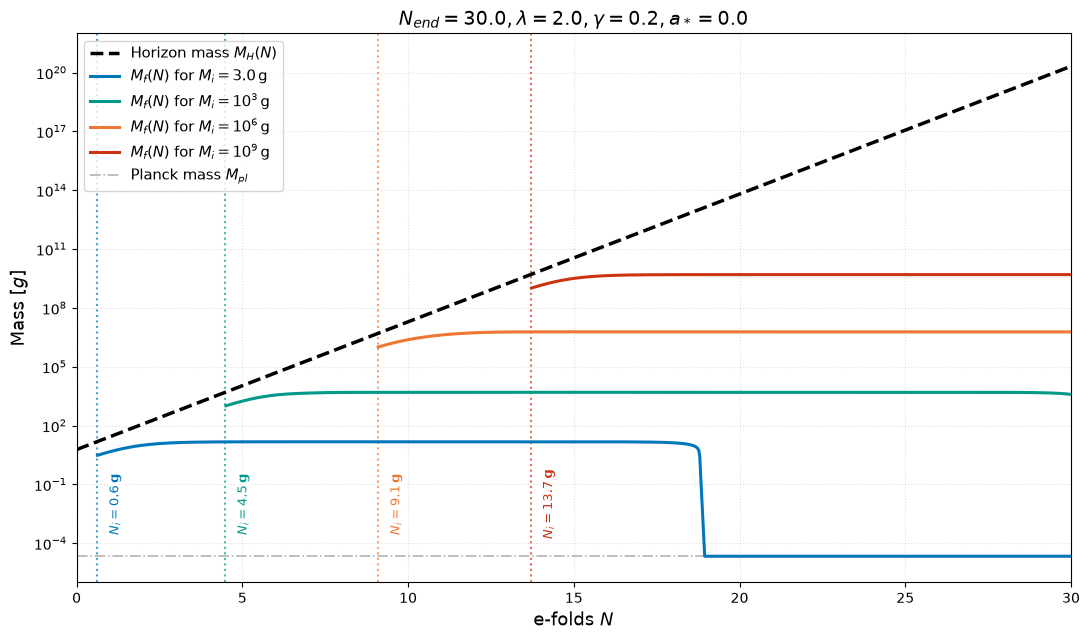

In [45]:
# ---------------------------------------------------------------------------
# Cuadrícula oficial limpia de BlackHawk (50 puntos de fM.txt)
# ---------------------------------------------------------------------------
SPINS_GRID = jnp.array([
    0.0     , 0.001   , 0.001931, 0.003728, 0.007197, 0.013895, 0.026827,
    0.051795, 0.1     , 0.136364, 0.172727, 0.209091, 0.245455, 0.281818,
    0.318182, 0.354545, 0.390909, 0.427273, 0.463636, 0.5     , 0.536364,
    0.572727, 0.609091, 0.645455, 0.681818, 0.718182, 0.754545, 0.790909,
    0.827273, 0.863636, 0.9     , 0.930481, 0.951671, 0.966402, 0.976643,
    0.983762, 0.988712, 0.992152, 0.994544, 0.996207, 0.997363, 0.998167,
    0.998726, 0.999114, 0.999384, 0.999572, 0.999702, 0.999793, 0.999856,
    0.9999
])

XI_GRID = jnp.array([
    1.000000, 1.000002, 1.000010, 1.000034, 1.000126, 1.000466, 1.001740,
    1.006490, 1.024294, 1.045415, 1.073376, 1.108473, 1.151091, 1.201727,
    1.260982, 1.329635, 1.408670, 1.499308, 1.603133, 1.722095, 1.858833,
    2.016765, 2.200552, 2.416409, 2.673523, 2.984786, 3.370252, 3.862211,
    4.515014, 5.430194, 6.826142, 8.746920, 11.00065, 13.70851, 16.23714,
    18.93846, 21.71151, 24.84989, 29.80999, 32.11677, 34.20102, 36.28527,
    38.06681, 39.44684, 40.28592, 41.22712, 41.24674, 43.41100, 44.95941,
    45.10467
])

def kerr_evap_factor(a_star):
    """
    Factor continuo xi(a*) = f(M, a*) / f(M, 0) calibrado con BlackHawk.
    """
    a = jnp.clip(a_star, 0.0, 0.9999)
    return jnp.interp(a, SPINS_GRID, XI_GRID)


@eqx.filter_jit
def trayectoria_pbh_vs_horizonte(Mi_val_g, N_fin, a_star, lam=2.0, gamma=0.2, N_puntos=1000):
    # Constantes
    M_pl_GeV = 1.22089e19
    M_pl_g = 2.17645e-5
    H_end_GeV = 4.44e13 
    
    M_i_pl = Mi_val_g / M_pl_g
    H_end_pl = H_end_GeV / M_pl_GeV
    M_end_pl = 1.0 / H_end_pl
    
    # 1. Corrección de formación usando gamma
    N_ini = (2.0 / 3.0) * jnp.log(jnp.maximum((M_i_pl / gamma) / M_end_pl, 1.0))
    a_star_safe = jnp.clip(a_star, 0.0, 0.9999)

    # ---------------------------------------------------------
    # Parámetros del Campo Escalar
    # ---------------------------------------------------------
    n_scalar = 100.0 
    mu_pl = n_scalar * H_end_pl 
    rho_end_inf_pl = (3.0 * H_end_pl**2.0) / (8.0 * jnp.pi)
    phi_ini_pl = jnp.sqrt(2.0 * rho_end_inf_pl / (mu_pl**2.0 + 9.0 * H_end_pl**2.0 / 4.0))

    # Factores de espín para la acreción
    raiz_espin = jnp.sqrt(1.0 - a_star_safe**2.0)
    factor_espin_acc = ((1.0 + raiz_espin) / 2.0)**2.0
    lambda_eff_base = lam * factor_espin_acc

    # Factor de evaporación calibrado con BlackHawk
    factor_evap_kerr = kerr_evap_factor(a_star_safe)

    def Hubble(N):
        return H_end_pl * jnp.exp(-1.5 * N)
        
    def rho_inf_field_env(N):
        return 0.5 * (phi_ini_pl * mu_pl)**2 * jnp.exp(-3.0 * N)

    def vector_field_log(N, u, args):
        H_val = Hubble(N)
        M_H_actual = 1.0 / H_val
        
        # Blindaje numérico
        u_H = jnp.log(M_H_actual)
        u_safe = jnp.clip(u, 0.0, u_H)  # El piso físico en u=0 equivale a M = M_pl
        M_actual = jnp.exp(u_safe)
        
        x = M_actual / M_H_actual
        
        # ---------------------------------------------------------
        # Dinámica de acreción y evaporación
        # ---------------------------------------------------------
        rho_phi = rho_inf_field_env(N)
        rho_crit = 3.0 * H_val**2.0 / (8.0 * jnp.pi)
        Omega_phi = rho_phi / rho_crit
        
        z = 2.0 * M_actual * mu_pl
        S_onda = (z**2.0) / (1.0 + z**2.0)
        
        # Acreción de onda
        dlnM_dN_acc = 3.0 * (lambda_eff_base * S_onda) * x * Omega_phi
        
        # Evaporación térmica
        dM_dt_evap_pl = - (1.0 / (3.0 * jnp.maximum(M_actual**2.0, 1.0))) * factor_evap_kerr
        dlnM_dN_evap = (dM_dt_evap_pl / H_val) / M_actual
        
        du_dN_val = dlnM_dN_acc + dlnM_dN_evap
        
        # REGULADOR DE RIGIDEZ (STIFFNESS):
        # Evita que du/dN -> -inf agote los pasos del integrador adaptativo
        du_dN_val = jnp.clip(du_dN_val, -80.0, 50.0)
        
        # Si ya alcanzó la masa de Planck (u <= 0), se congela en reliquia estable
        du_dN_val = jnp.where(u <= 0.0, 0.0, du_dN_val)
        
        # Solo evoluciona para N >= N_ini
        return jnp.where(N < N_ini, 0.0, du_dN_val)

    # Malla temporal
    ts_eval = jnp.linspace(0.0, N_fin, N_puntos)
    saveat = SaveAt(ts=ts_eval)
    
    term = ODETerm(vector_field_log)
    solver = Tsit5()
    stepsize_controller = PIDController(rtol=1e-4, atol=1e-4, jump_ts=jnp.array([N_ini]))

    u_0 = jnp.log(jnp.maximum(M_i_pl, 1.0))
    dt0_val = (N_fin / N_puntos) * 0.5
    
    sol = diffeqsolve(
        term, 
        solver, 
        t0=0.0, 
        t1=N_fin, 
        dt0=dt0_val, 
        y0=u_0, 
        args=a_star_safe,
        stepsize_controller=stepsize_controller, 
        saveat=saveat, 
        max_steps=50000,
        throw=False
    )
    
    # En unidades de Planck, la reliquia final tiene u = 0 -> M = M_pl
    u_arr = jnp.maximum(sol.ys, 0.0)
    M_pbh_g = jnp.exp(u_arr) * M_pl_g

    # Horizonte de Hubble
    M_H_g = (1.0 / Hubble(ts_eval)) * M_pl_g

    return ts_eval, M_pbh_g, M_H_g, N_ini

def plot_horizonte_vs_pbh():
    N_fin = 30.0
    a_star = 0.0
    lam_efectivo = 2.0
    gamma_val = 0.2
    
    masas_prueba = [3.0, 1e3, 1e6, 1e9]  
    colores = ['#0077BB', '#009988', '#EE7733', '#CC3311']

    plt.figure(figsize=(11, 6.5))

    # Trazar la evolución del horizonte de Hubble
    N_grid, _, M_H_g, _ = trayectoria_pbh_vs_horizonte(
        masas_prueba[0], N_fin, a_star, lam=lam_efectivo, gamma=gamma_val
    )
    plt.plot(N_grid, M_H_g, color='black', linestyle='--', lw=2.5, label=r'Horizon mass $M_H(N)$', zorder=2)

    for idx, M_i in enumerate(masas_prueba):
        _, M_pbh_g, _, N_ini = trayectoria_pbh_vs_horizonte(
            M_i, N_fin, a_star, lam=lam_efectivo, gamma=gamma_val
        )
        
        # Enmascarar antes de la formación para no trazar líneas planas no físicas
        M_plot = np.array(M_pbh_g)
        M_plot[N_grid < float(N_ini)] = np.nan
        
        # Etiqueta limpia para masas no enteras en log10 (e.g., 3.0 g)
        if M_i < 10.0:
            label_curva = rf'$M_f(N)$ for $M_i = {M_i:.1f}\,$g'
        else:
            label_curva = rf'$M_f(N)$ for $M_i = 10^{{{int(np.log10(M_i))}}}\,$g'

        plt.plot(N_grid, M_plot, color=colores[idx], lw=2.2, label=label_curva, zorder=3)
        
        # Línea vertical indicando el e-fold exacto de formación
        plt.axvline(x=float(N_ini), color=colores[idx], linestyle=':', alpha=0.7, zorder=1)
        y_pos = 1e-2
        x_text_pos = N_ini + 0.35
        
        plt.text(
            x_text_pos, y_pos, 
            rf'$N_{{i}} = {N_ini:.1f}\,$g', 
            color=colores[idx], 
            rotation=90, 
            verticalalignment='center', 
            horizontalalignment='left',
            fontsize=9.5, 
            fontweight='bold',
            zorder=5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.65, edgecolor='none')
        )

    # Línea horizontal de referencia para la masa de Planck
    plt.axhline(y=M_pl_g, color='gray', linestyle='-.', lw=1.2, alpha=0.6, label=r'Planck mass $M_{pl}$')

    plt.yscale('log')
    plt.xlabel(r'e-folds $N$', fontsize=13)
    plt.ylabel(r'Mass $[g]$', fontsize=13)
    plt.title(rf'$N_{{end}} = {N_fin}, \lambda = {lam_efectivo}, \gamma = {gamma_val}, a_* = {a_star}$', fontsize=14)
    
    plt.xlim(0, N_fin)
    
    # CORRECCIÓN PRINCIPAL: Bajar el límite inferior hasta 1e-6 g para ver la evaporación completa
    plt.ylim(1e-6, 1e22)
    
    plt.grid(True, which='both', ls=':', alpha=0.4)
    plt.legend(fontsize=10.5, loc='upper left')
    plt.tight_layout()
    plt.savefig('massvshz.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    plot_horizonte_vs_pbh()

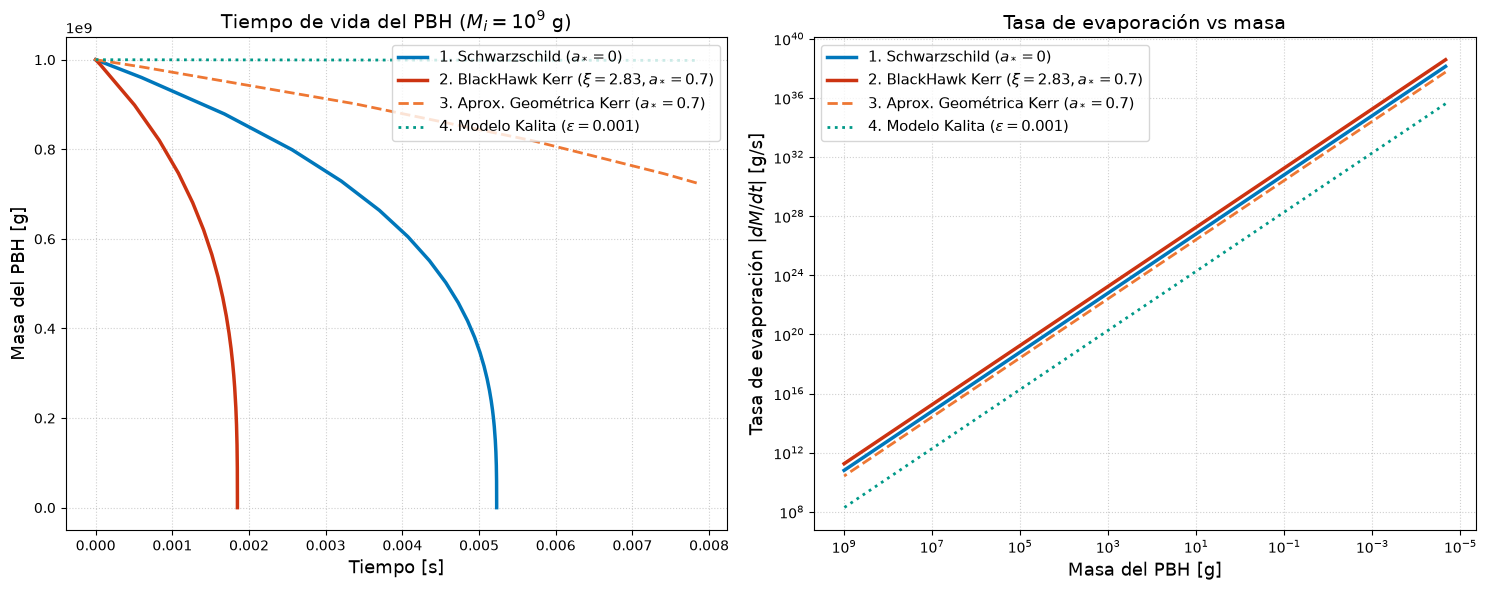

In [9]:
from scipy.integrate import solve_ivp

M_pl_g = 2.17645e-5
t_pl_s = 5.391247e-44

# ---------------------------------------------------------------------------
# Cuadrícula oficial limpia de BlackHawk (50 puntos de fM.txt)
# ---------------------------------------------------------------------------
SPINS_GRID = np.array([
    0.0     , 0.001   , 0.001931, 0.003728, 0.007197, 0.013895, 0.026827,
    0.051795, 0.1     , 0.136364, 0.172727, 0.209091, 0.245455, 0.281818,
    0.318182, 0.354545, 0.390909, 0.427273, 0.463636, 0.5     , 0.536364,
    0.572727, 0.609091, 0.645455, 0.681818, 0.718182, 0.754545, 0.790909,
    0.827273, 0.863636, 0.9     , 0.930481, 0.951671, 0.966402, 0.976643,
    0.983762, 0.988712, 0.992152, 0.994544, 0.996207, 0.997363, 0.998167,
    0.998726, 0.999114, 0.999384, 0.999572, 0.999702, 0.999793, 0.999856,
    0.9999
])

XI_GRID = np.array([
    1.000000, 1.000002, 1.000010, 1.000034, 1.000126, 1.000466, 1.001740,
    1.006490, 1.024294, 1.045415, 1.073376, 1.108473, 1.151091, 1.201727,
    1.260982, 1.329635, 1.408670, 1.499308, 1.603133, 1.722095, 1.858833,
    2.016765, 2.200552, 2.416409, 2.673523, 2.984786, 3.370252, 3.862211,
    4.515014, 5.430194, 6.826142, 8.746920, 11.00065, 13.70851, 16.23714,
    18.93846, 21.71151, 24.84989, 29.80999, 32.11677, 34.20102, 36.28527,
    38.06681, 39.44684, 40.28592, 41.22712, 41.24674, 43.41100, 44.95941,
    45.10467
])

def kerr_evap_factor(a_star):
    """Interpolación del factor xi(a*) = f(M, a*) / f(M, 0) de BlackHawk."""
    a = np.clip(a_star, 0.0, 0.9999)
    return np.interp(a, SPINS_GRID, XI_GRID)

def comparar_evaporacion(M_i_g=1e9, a_star=0.9):
    # 1. Transformación a unidades de Planck
    M_i_pl = M_i_g / M_pl_g
    a_safe = np.clip(a_star, 0.0, 0.9999)
    
    # 2. Factores de evaporación
    # A) Factor BlackHawk (numérico exacto con emisión de todos los campos + gravitón)
    factor_bh = kerr_evap_factor(a_safe)
    
    # B) Aproximación analítica previa geométrica (T^4 * Área)
    raiz_espin = np.sqrt(1.0 - a_safe**2)
    factor_T = (2.0 * raiz_espin) / (1.0 + raiz_espin)
    factor_A = 0.5 * (1.0 + raiz_espin)
    factor_kerr_geom = (factor_T**4) * factor_A
    
    # C) Modelo fenomenológico (Kalita)
    epsilon = 1e-3

    # 3. Ecuaciones diferenciales dM/dt en unidades de Planck
    def rhs_sch(t, M):   return [- (1.0 / 3.0) / M[0]**2]
    def rhs_bh(t, M):    return [- (1.0 / 3.0) * factor_bh / M[0]**2]
    def rhs_geom(t, M):  return [- (1.0 / 3.0) * factor_kerr_geom / M[0]**2]
    def rhs_usr(t, M):   return [- epsilon / M[0]**2]
    
    def evento_fin(t, M): return M[0] - 1.1
    evento_fin.terminal = True
    
    # 4. Integración dinámica
    t_sch_pl = (M_i_pl**3)  # Escala analítica tau ~ M^3 / (1/3) * (1/3)
    t_max_pl = t_sch_pl * 1.5
    
    sol_sch  = solve_ivp(rhs_sch,  [0, t_max_pl], [M_i_pl], events=evento_fin, rtol=1e-7, atol=1e-7)
    sol_bh   = solve_ivp(rhs_bh,   [0, t_max_pl], [M_i_pl], events=evento_fin, rtol=1e-7, atol=1e-7)
    sol_geom = solve_ivp(rhs_geom, [0, t_max_pl], [M_i_pl], events=evento_fin, rtol=1e-7, atol=1e-7)
    sol_usr  = solve_ivp(rhs_usr,  [0, t_max_pl], [M_i_pl], events=evento_fin, rtol=1e-7, atol=1e-7)
    
    # 5. Graficación
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # --- Panel 1: Evolución de la masa en el tiempo ---
    ax1.plot(sol_sch.t * t_pl_s, sol_sch.y[0] * M_pl_g, label='1. Schwarzschild ($a_*=0$)', lw=2.5, color='#0077BB')
    ax1.plot(sol_bh.t * t_pl_s, sol_bh.y[0] * M_pl_g, label=rf'2. BlackHawk Kerr ($\xi={factor_bh:.2f}, a_*={a_star}$)', lw=2.5, color='#CC3311')
    ax1.plot(sol_geom.t * t_pl_s, sol_geom.y[0] * M_pl_g, label=rf'3. Aprox. Geométrica Kerr ($a_*={a_star}$)', lw=2.0, ls='--', color='#EE7733')
    ax1.plot(sol_usr.t * t_pl_s, sol_usr.y[0] * M_pl_g, label=rf'4. Modelo Kalita ($\epsilon={epsilon}$)', lw=2.0, ls=':', color='#009988')
    
    ax1.set_xlabel('Tiempo [s]', fontsize=13)
    ax1.set_ylabel('Masa del PBH [g]', fontsize=13)
    ax1.set_title(f'Tiempo de vida del PBH ($M_i = 10^{{{int(np.log10(M_i_g))}}}$ g)', fontsize=14)
    ax1.grid(True, ls=':', alpha=0.6)
    ax1.legend(fontsize=10.5, loc ='upper right')
    
    # --- Panel 2: Tasa instantánea de evaporación |dM/dt| ---
    M_arr_pl = np.logspace(0, np.log10(M_i_pl), 500)
    M_arr_g = M_arr_pl * M_pl_g
    
    rate_sch  = ((1.0 / 3.0) / M_arr_pl**2) * (M_pl_g / t_pl_s)
    rate_bh   = ((1.0 / 3.0) * factor_bh / M_arr_pl**2) * (M_pl_g / t_pl_s)
    rate_geom = ((1.0 / 3.0) * factor_kerr_geom / M_arr_pl**2) * (M_pl_g / t_pl_s)
    rate_usr  = (epsilon / M_arr_pl**2) * (M_pl_g / t_pl_s)
    
    ax2.plot(M_arr_g, rate_sch, label='1. Schwarzschild ($a_*=0$)', lw=2.5, color='#0077BB')
    ax2.plot(M_arr_g, rate_bh, label=rf'2. BlackHawk Kerr ($\xi={factor_bh:.2f}, a_*={a_star}$)', lw=2.5, color='#CC3311')
    ax2.plot(M_arr_g, rate_geom, label=rf'3. Aprox. Geométrica Kerr ($a_*={a_star}$)', lw=2.0, ls='--', color='#EE7733')
    ax2.plot(M_arr_g, rate_usr, label=rf'4. Modelo Kalita ($\epsilon={epsilon}$)', lw=2.0, ls=':', color='#009988')
    
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Masa del PBH [g]', fontsize=13)
    ax2.set_ylabel(r'Tasa de evaporación $|dM/dt|$ [g/s]', fontsize=13)
    ax2.set_title('Tasa de evaporación vs masa', fontsize=14)
    ax2.invert_xaxis()
    ax2.grid(True, which='both', ls=':', alpha=0.6)
    ax2.legend(fontsize=10.5)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    comparar_evaporacion(M_i_g=1e9, a_star=0.7)